In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

Here we added the libraries as 

1)Matplotlib is a fundamental, open-source Python library for creating static, animated, and interactive data visualizations.Matplotlib can generate a wide range of visualizations with just a few lines of code, including line plots, scatter plots, bar charts, histograms, pie charts, and 3D plots.

2)Seaborn is a popular Python library for creating attractive and informative statistical graphics.

3)The scipy.stats.ttest_ind function in Python's SciPy library calculates the T-test for the means of two independent samples of scores SciPy library calculates the T-test for the means of two independent samples of scores. It is a widely used function for hypothesis testing to determine if two groups have significantly different average values.

In [3]:
#creating connection to the database
conn = sqlite3.connect('C:\\Vendor project\\data1.db')

#feteching data from the database
df=pd.read_sql_query("""SELECT * FROM Vendor_sales_summary""", conn)

In [4]:
#summary statistics of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


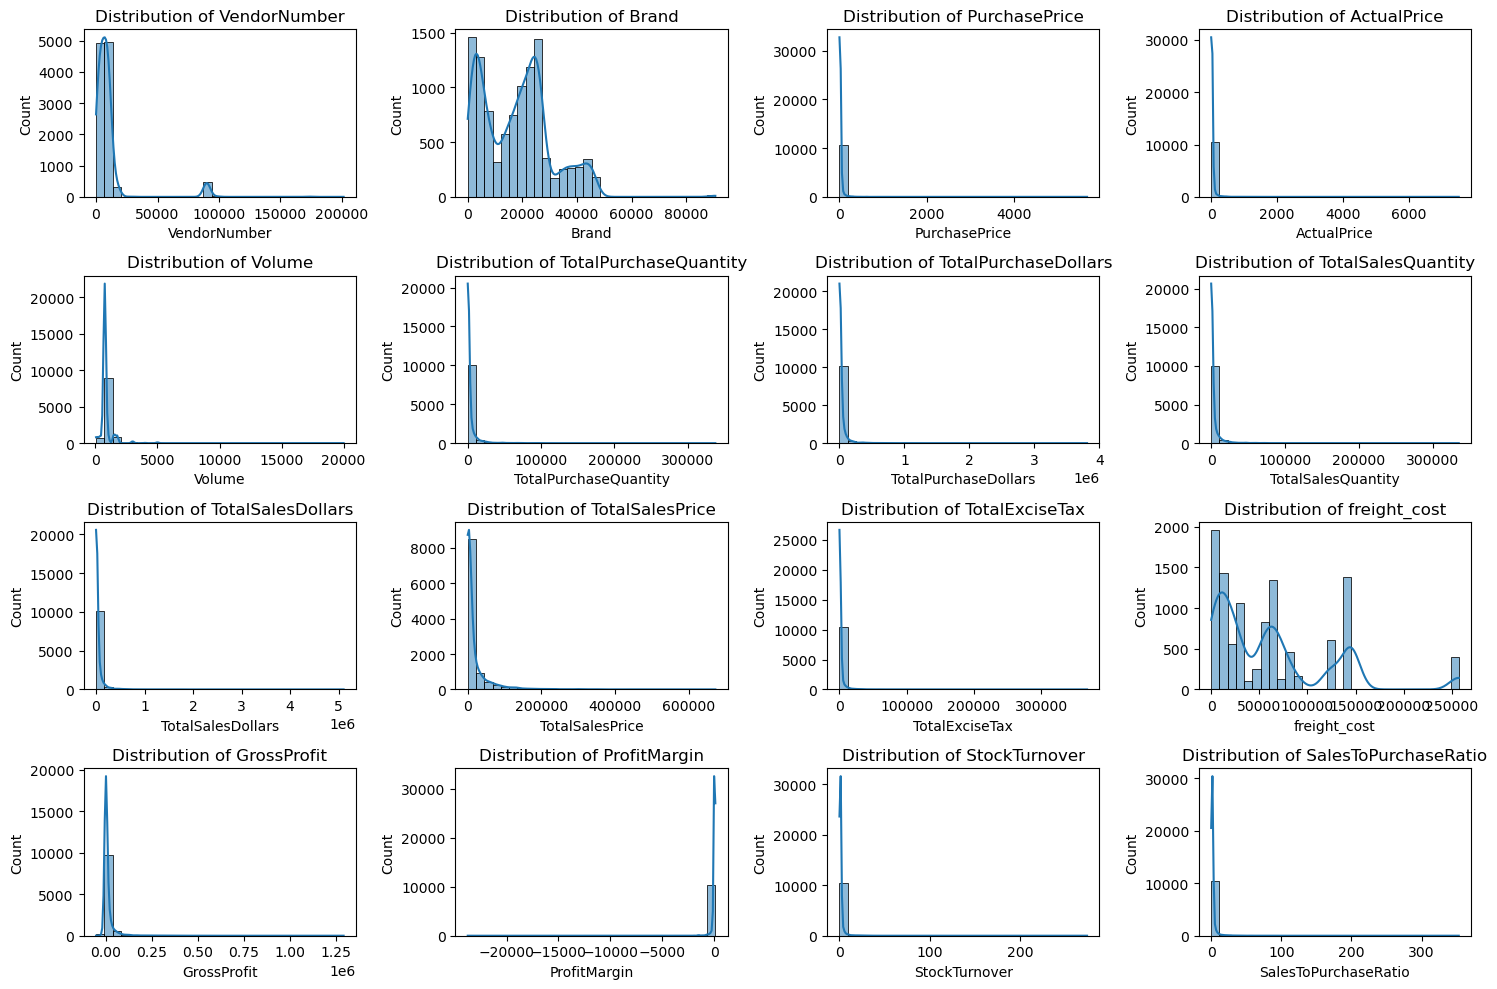

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=True,bins=30)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()    

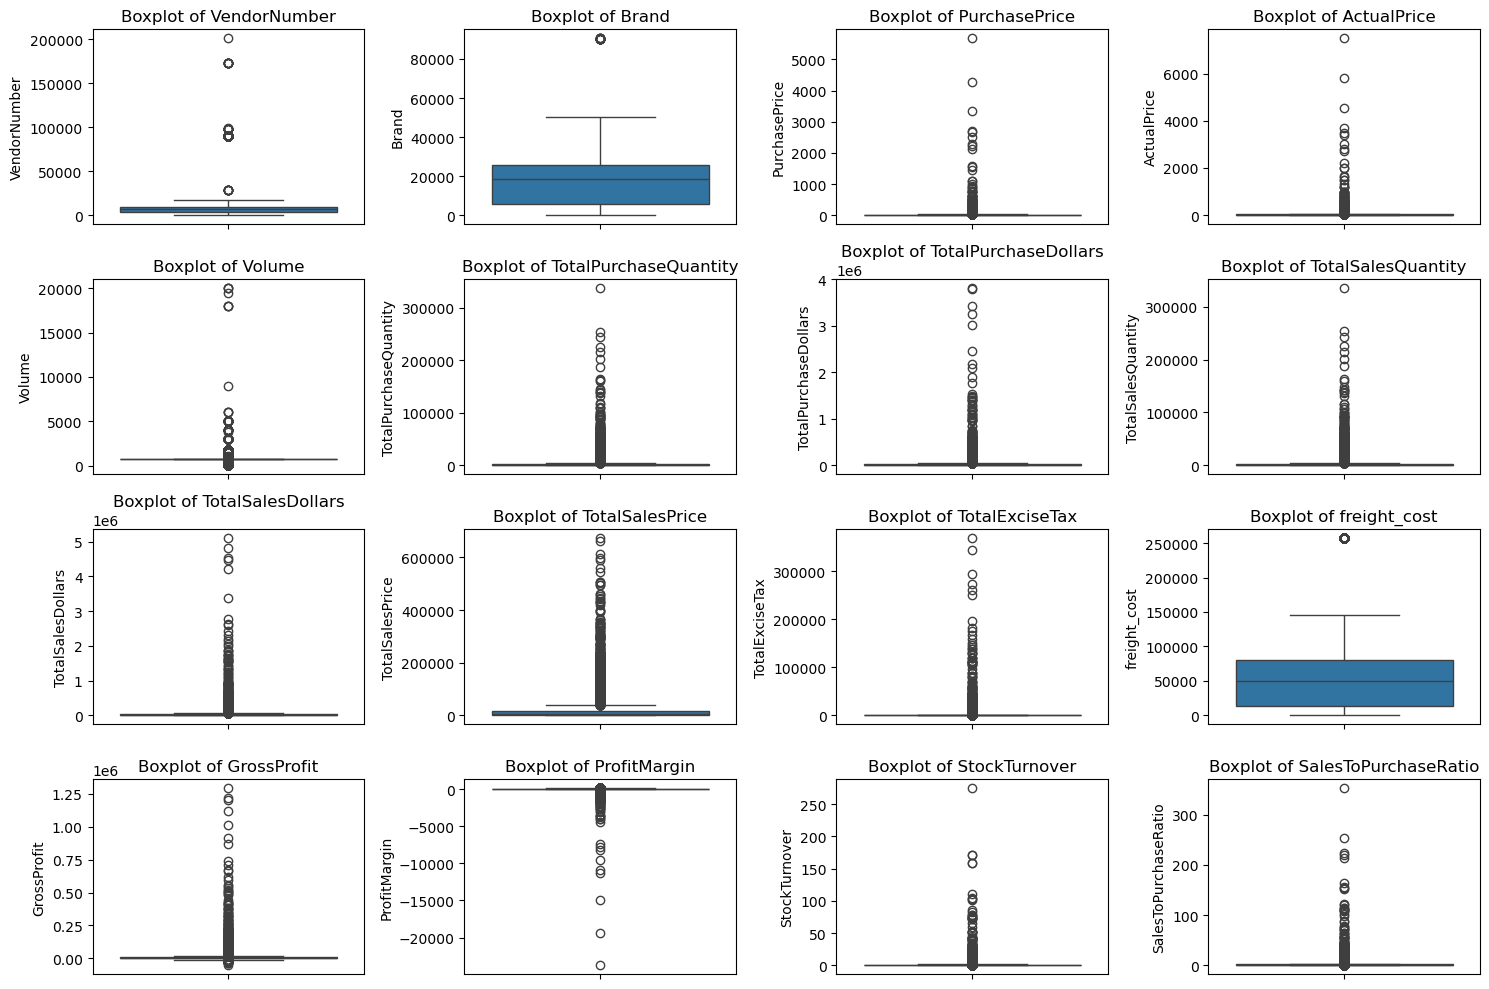

In [ ]:
# It is used to know outliers in the data and to know the spread of the data.

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()    

So from the above charts and the describe infromation we get to know in profit margin, gross profit and totalsalesquantity need to be above the zero it is not use of such values which is below zero so we filter out here. 

In [7]:
#filtering the data
df=pd.read_sql_query("""SELECT * FROM Vendor_sales_summary where
                       ProfitMargin > 0 AND
                       GrossProfit > 0 AND
                       TotalSalesquantity > 0""",conn )


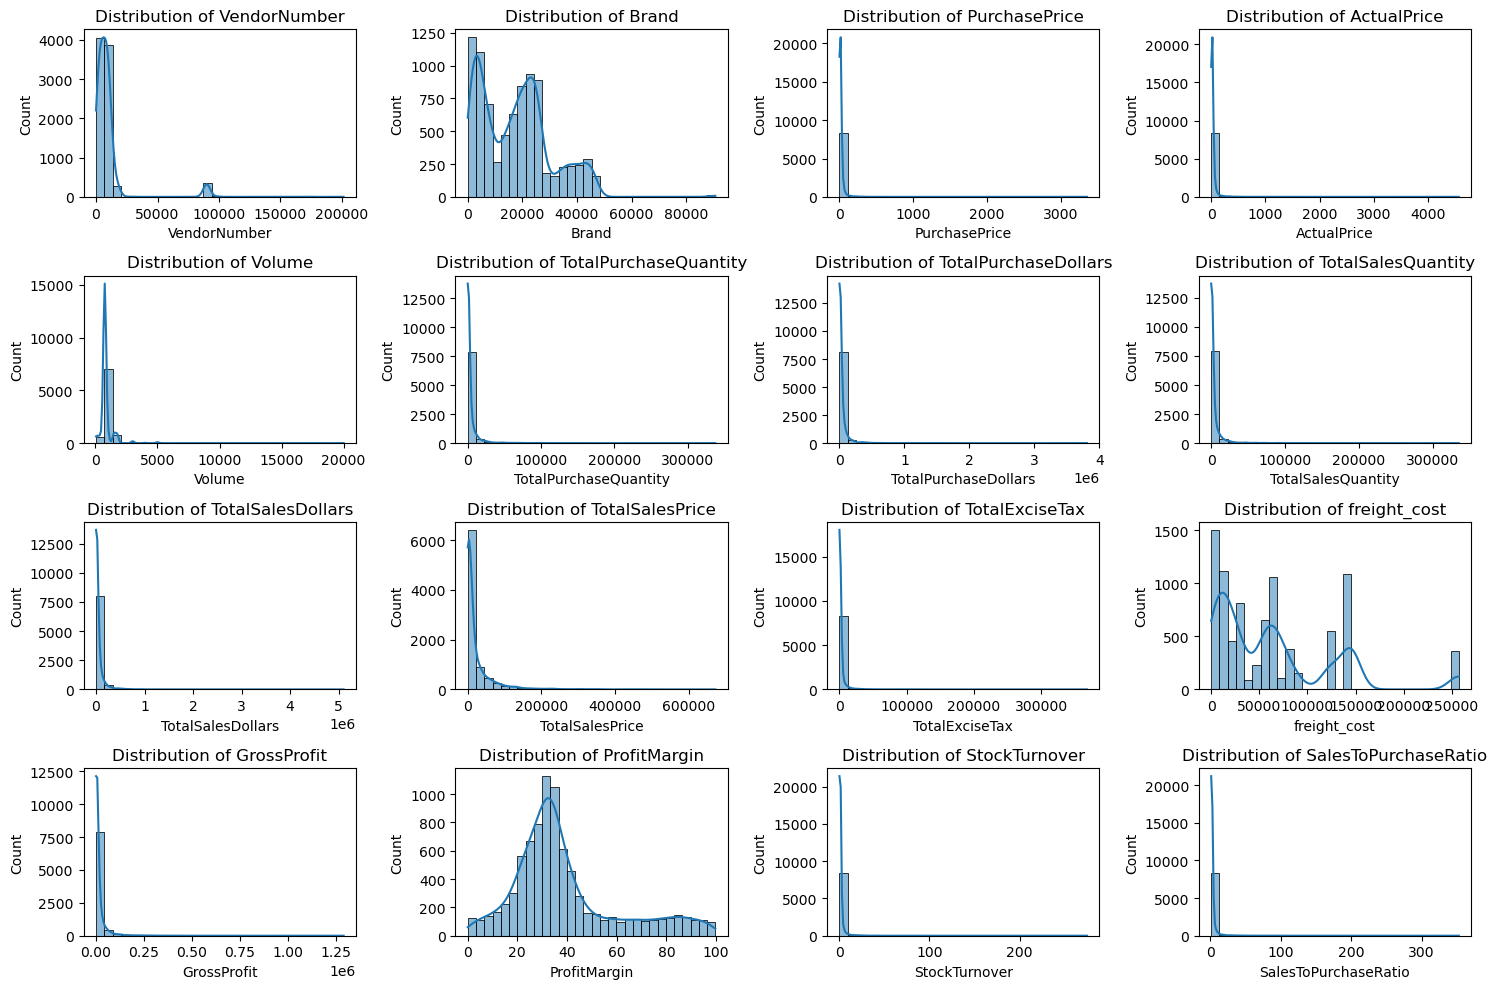

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=True,bins=30)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()    

To see number of  top 10 vendor names and products present in the table .

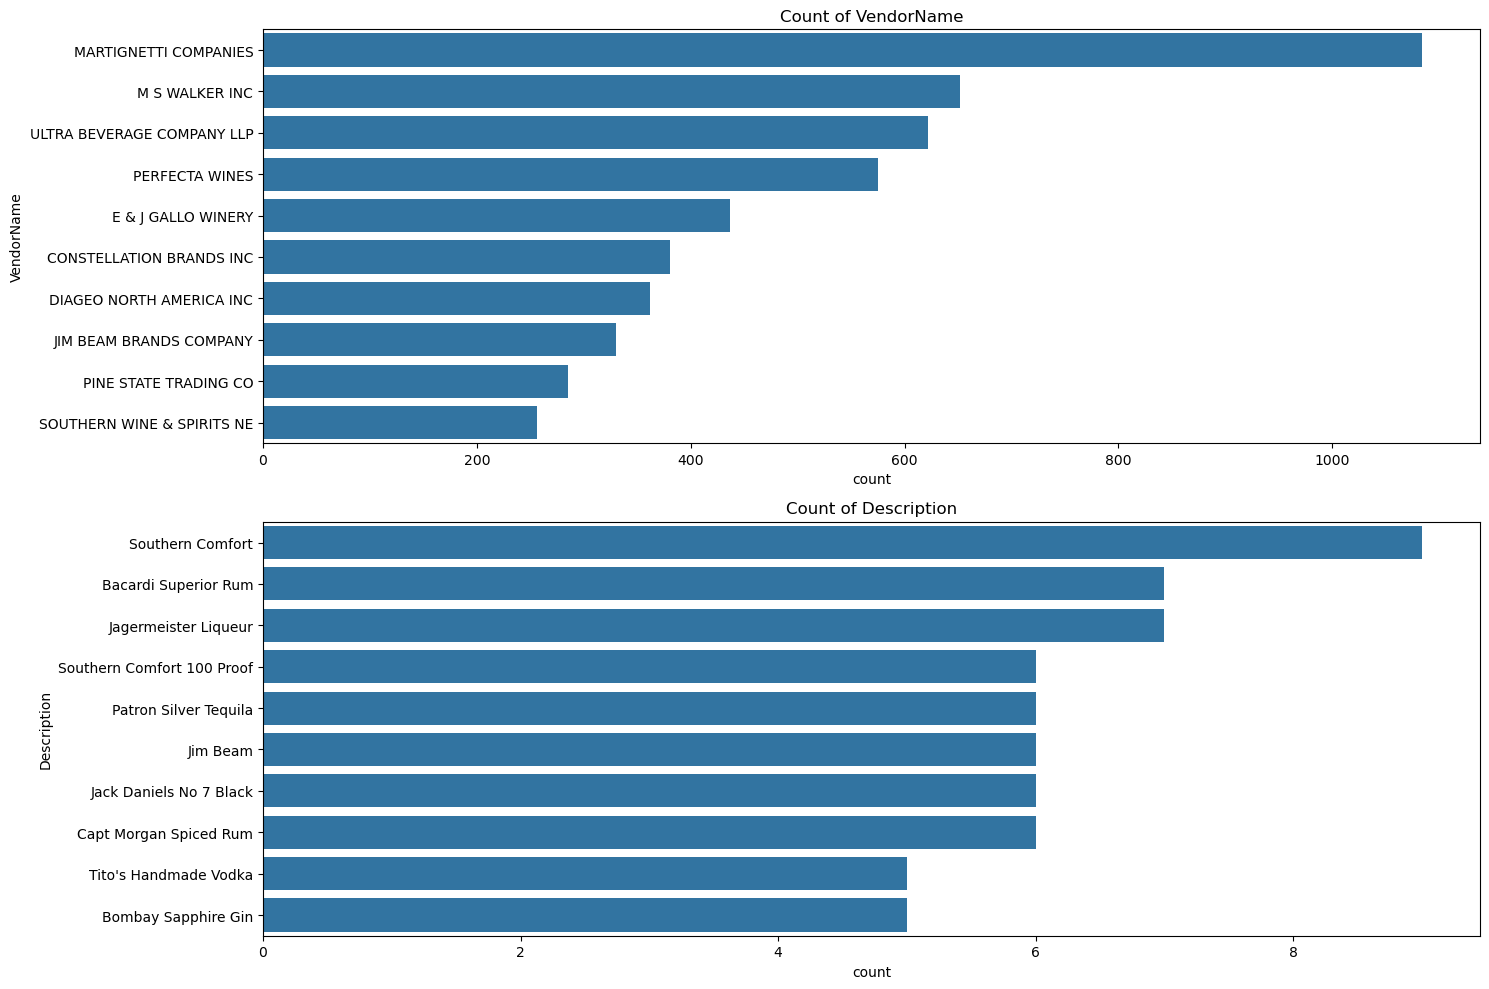

In [ ]:
#Top 10  vendors and brands count
categorical_cols=["VendorName","Description"]
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 1, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])   #Top 10 categories

    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()    

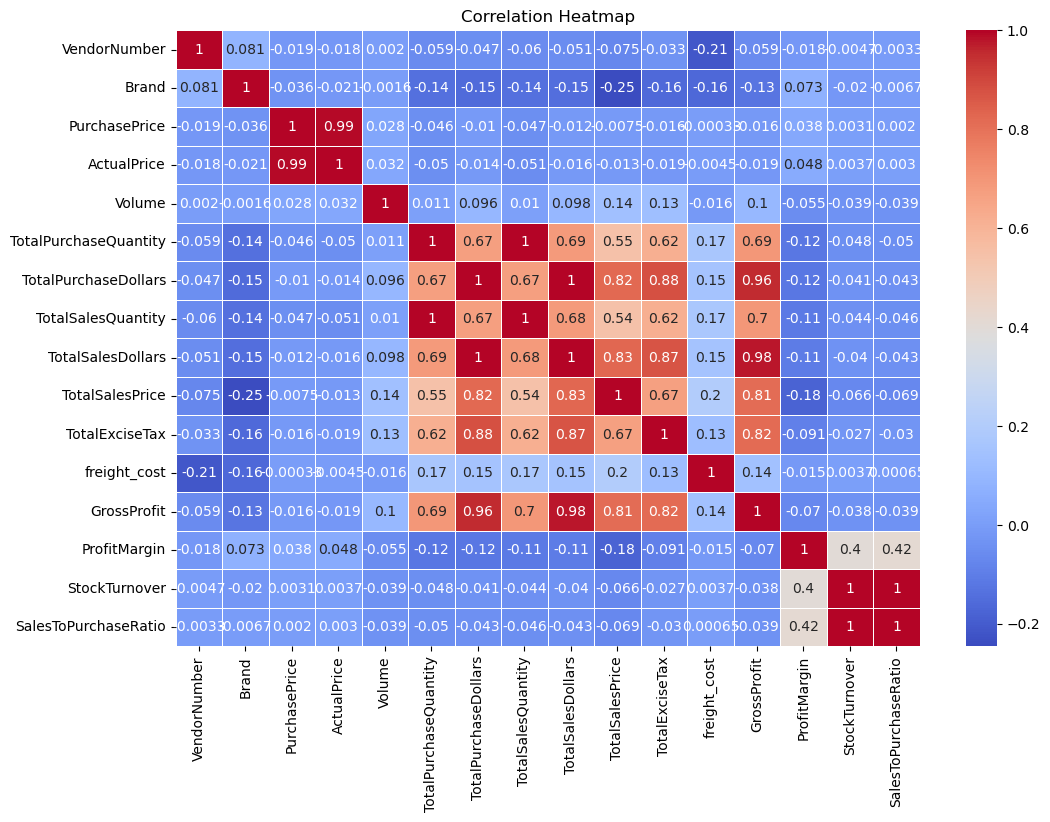

In [ ]:
# It is used to find the correlation between the numerical variables and to find the relationship between them.

plt.figure(figsize=(12, 8))
corelation_matrix = df[numerical_cols].corr()
sns.heatmap(corelation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Coorelation Insights

1)Purchaseprice has weak corelation with TotalsalesDollars(-0.012) and GrossProfit (-0.016) suggesting that price variations don't significantly impact sales revenue and profit.
2)Strong coorelation between total purchase quantity and total sales quantity(0.99) .
3)Negative corelation between profit margin and total sales price (-0.18) which has weak inverse relationship between each other.
4)There is strong relation between the total sales dollars and total purchase dollars with the gross profit.

Identify the brands that needs promotional and pricing adjustments which exhibit lower sales performance but higher profit margins.

In [11]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum','ProfitMargin':'sum'}).reset_index()

Here we consider as the vendors which has totalsalesdollars less than 15 percentile and profit margin more than 85 percentile . Also we have filter out brands whose sales less than 10000 dollars for better visualization.

In [12]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
low_sales_threshold, high_margin_threshold

(np.float64(560.299), np.float64(73.53875892464183))

In [ ]:
target_brands=brand_performance[(brand_performance['TotalSalesDollars'] <= low_sales_threshold)
                                 & (brand_performance['ProfitMargin'] >= high_margin_threshold)]

print("Target Brands for Improvement:")
display(target_brands.sort_values(by='TotalSalesDollars'))

In [ ]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000]   
 #for better visualization we filtered out the brands with less than 10000 sales dollars

In [ ]:
plt.figure(figsize=(10 , 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin',color='blue', alpha=0.6, label='All Brands')
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin',color='red', alpha=0.8, label='Target Brands')
plt.axvline(x=low_sales_threshold, color='green', linestyle='--', label='Low Sales Threshold')
plt.axhline(y=high_margin_threshold, color='orange', linestyle='--', label='High Margin Threshold')
plt.title('Brand Performance Encouragement')
plt.xlabel('Total Sales Dollars')
plt.ylabel('Profit Margin')
plt.legend()
plt.grid(True)
plt.show()

Also we want to find the low performing vendors and brands 

In [17]:
# Low performing vendors and brands according to the total sales dollars and profit margin.

low_performance_vendors= df.groupby('VendorName').agg({
    'TotalSalesDollars':'sum','ProfitMargin':'sum'}).reset_index()

low_performance_brands= df.groupby('Description').agg({
    'TotalSalesDollars':'sum','ProfitMargin':'sum'}).reset_index()

low_vendors_threshold=low_performance_vendors['TotalSalesDollars']<10000
low_margin_threshold=low_performance_vendors['ProfitMargin']<low_performance_vendors['ProfitMargin'].quantile(0.10)

low_brands_threshold=low_performance_brands['TotalSalesDollars']<10000
low_margin_brands_threshold=low_performance_brands['ProfitMargin']<low_performance_brands['ProfitMargin'].quantile(0.10)

low_performance_vendors=low_performance_vendors[low_vendors_threshold & low_margin_threshold]
low_performance_brands=low_performance_brands[low_brands_threshold & low_margin_brands_threshold]



In [64]:
low_performance_vendors=low_performance_vendors.sort_values(by=['TotalSalesDollars', 'ProfitMargin'])
low_performance_brands=low_performance_brands.sort_values(by=['TotalSalesDollars', 'ProfitMargin'])

#Top 10 low performing vendors and brands for further analysis and improvement strategies.
top_10_low_performing_vendors = low_performance_vendors.head(10)
top_10_low_performing_brands = low_performance_brands.head(10)

print("Top 10 Low Performance Vendors:")
display(top_10_low_performing_vendors)

print("Top 10 Low Performance Brands:")
display(top_10_low_performing_brands)

Top 10 Low Performance Vendors:


,VendorName,TotalSalesDollars,ProfitMargin
107,UNCORKED,176.94,32.892506
0,ADAMBA IMPORTS INTL INC,704.53,36.672675
3,AMERICAN SPIRITS EXCHANGE,1511.16,38.187882
9,BLACK ROCK SPIRITS LLC,2049.18,43.777511
39,HAUNTING WHISPER VYDS,7325.89,52.168852


Top 10 Low Performance Brands:


,Description,TotalSalesDollars,ProfitMargin
4704,Mas Belles Eaux Les Cot Roug,50.97,9.770453
2770,Ezra Brooks Cinnamon Bourbon,56.97,3.282429
6124,S S Pierce Ninety Nine Gin,67.41,8.129358
4392,LiDestri Spicy Bloody Mary,71.92,2.558398
6398,Sileni Nano Pnt Nr,75.81,14.523150
2088,Conservancy Concannon Chard,77.94,1.963048
5127,Newman's Own Common Good Red,79.92,2.552553
4231,La Joya Svgn Blanc,83.93,3.491004
4395,Liberty Creek Merlot Tetra P,85.24,12.998592
5482,Pepe Lopez Premium Gold,99.90,10.390390


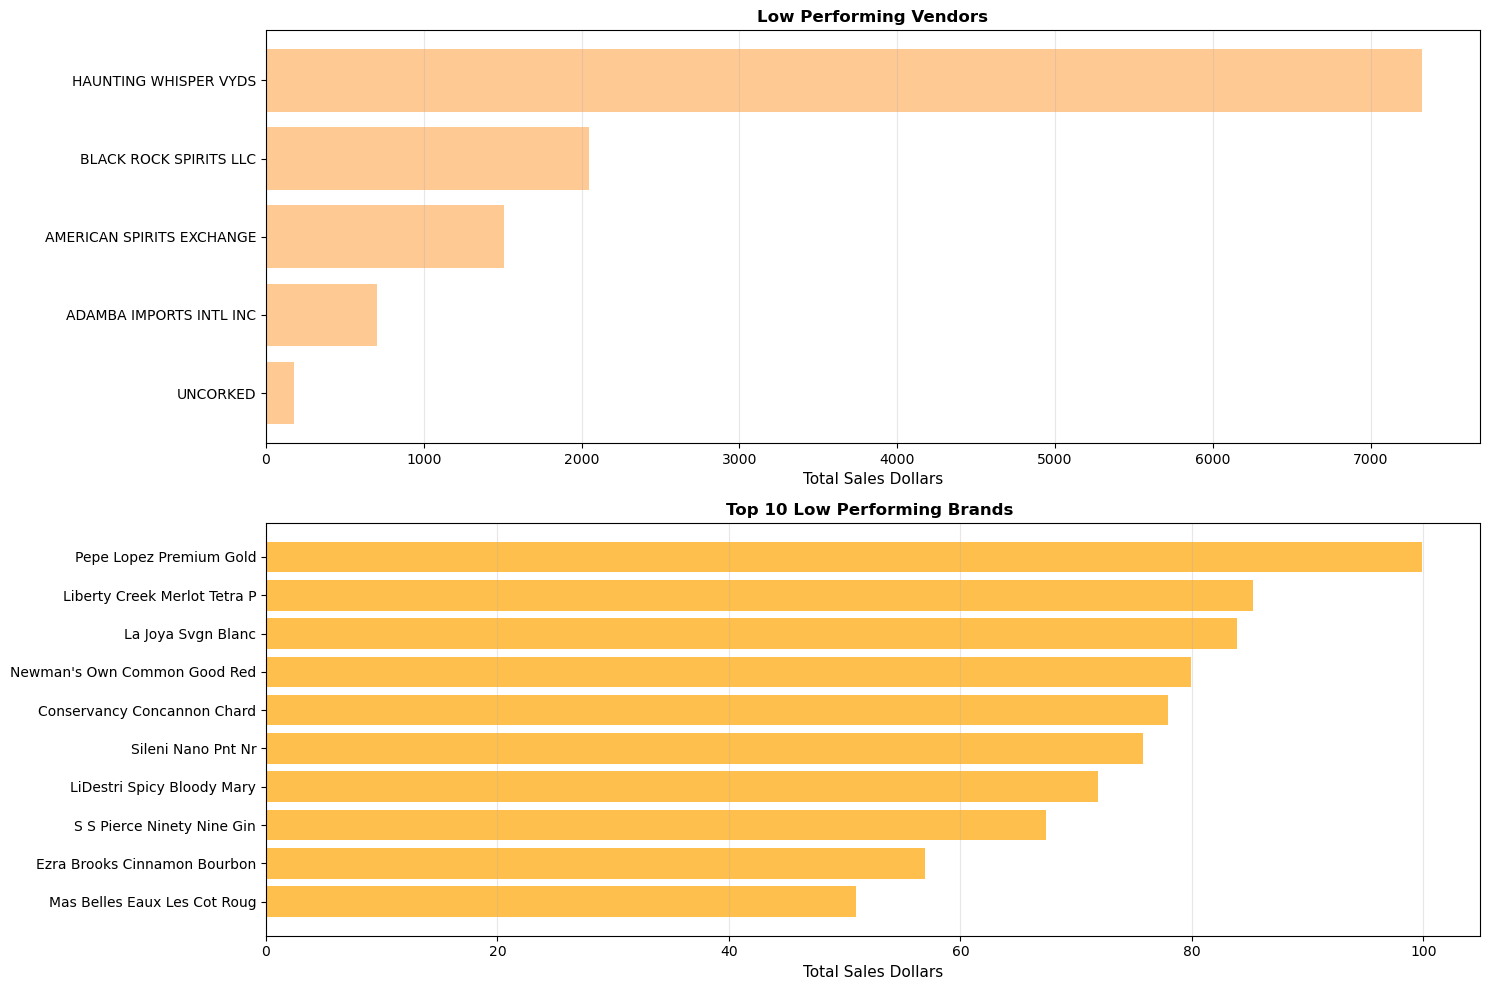

In [63]:
#visualization of low performance vendors and brands
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Vendors bar plot with light orange color
bars1 = axes[0].barh(top_10_low_performing_vendors['VendorName'], 
                     top_10_low_performing_vendors['TotalSalesDollars'],
                     color='#FFB366', alpha=0.7)
axes[0].set_xlabel('Total Sales Dollars', fontsize=11)
axes[0].set_title('Low Performing Vendors', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Brands bar plot
bars2 = axes[1].barh(top_10_low_performing_brands['Description'], 
                     top_10_low_performing_brands['TotalSalesDollars'], 
                     color='orange', alpha=0.7)
axes[1].set_xlabel('Total Sales Dollars', fontsize=11)
axes[1].set_title('Top 10 Low Performing Brands ', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Which vendors and brands demonstrate the high sales performance 

In [18]:
def format_dollars(values):
    if values >= 1000000:
        return f'{values/1000000:.2f}M'
    elif values >= 1000:
        return f'{values/1000:.2f}K'
    else:
        return str(values)

In [19]:
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_vendors.apply(lambda x: format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: object

In [20]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

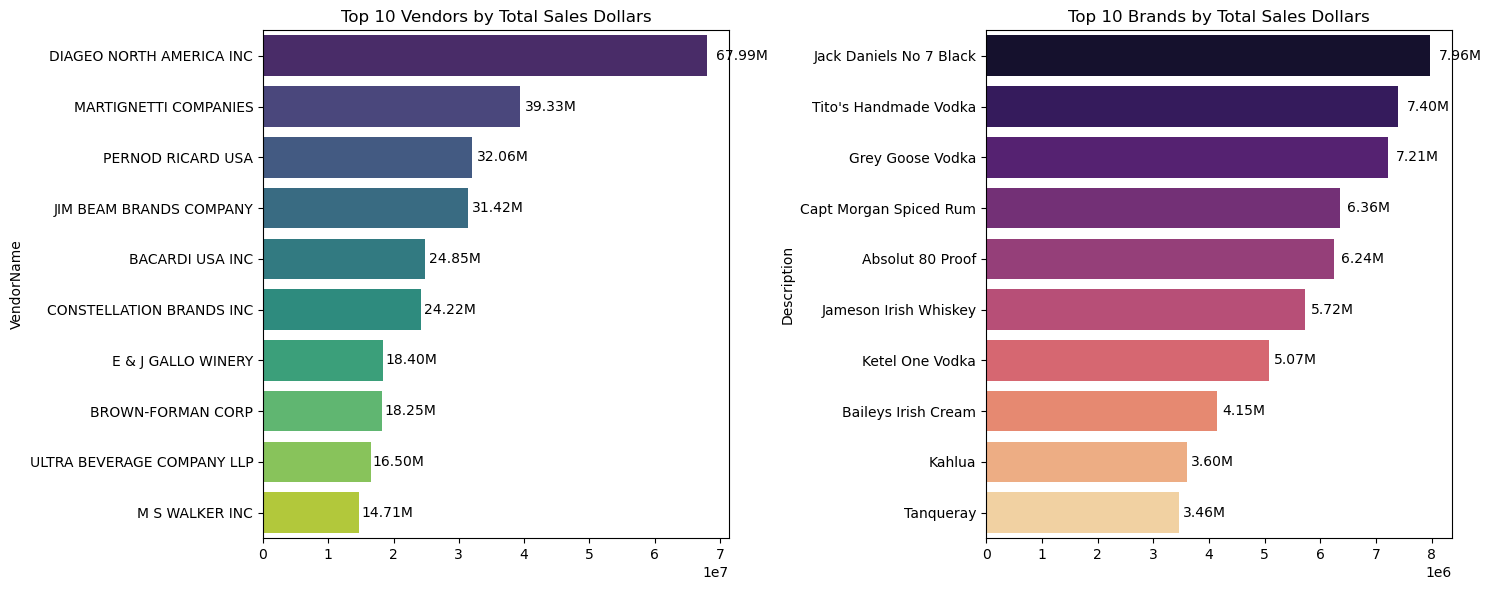

In [21]:
plt.figure(figsize=(15, 6))  #Top vendors 
plt.subplot(1, 2, 1)
ax1=sns.barplot(x=top_vendors.values, y=top_vendors.index, palette='viridis')
plt.title('Top 10 Vendors by Total Sales Dollars')

for bar in ax1.patches:
    ax1.text((bar.get_width()+ bar.get_width() * 0.02),
              bar.get_y() + bar.get_height() / 2,
                format_dollars(bar.get_width()), 
             va='center', ha='left', fontsize=10, color='black')


 #Top brands   
plt.subplot(1, 2, 2)
ax2=sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')
plt.title('Top 10 Brands by Total Sales Dollars')   


for bar in ax2.patches:
    ax2.text((bar.get_width()+ bar.get_width() *0.02),
              bar.get_y() + bar.get_height() / 2,
                format_dollars(bar.get_width()), 
             va='center', ha='left', fontsize=10, color='black')
    
plt.tight_layout()
plt.show()    

Which vendor contribute the most to total purchase dollars

In [22]:
vendor_performance1=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
    }).reset_index()
vendor_performance1

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [23]:
vendor_performance1['PurchaseContribution%']=vendor_performance1['TotalPurchaseDollars']/vendor_performance1['TotalPurchaseDollars'].sum() * 100

In [24]:
vendor_performance1=round(vendor_performance1.sort_values(by='PurchaseContribution%', ascending=False), 2)

In [25]:
top_vendors=vendor_performance1.head(10)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [26]:
top_vendors['CumulativeContribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,CumulativeContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


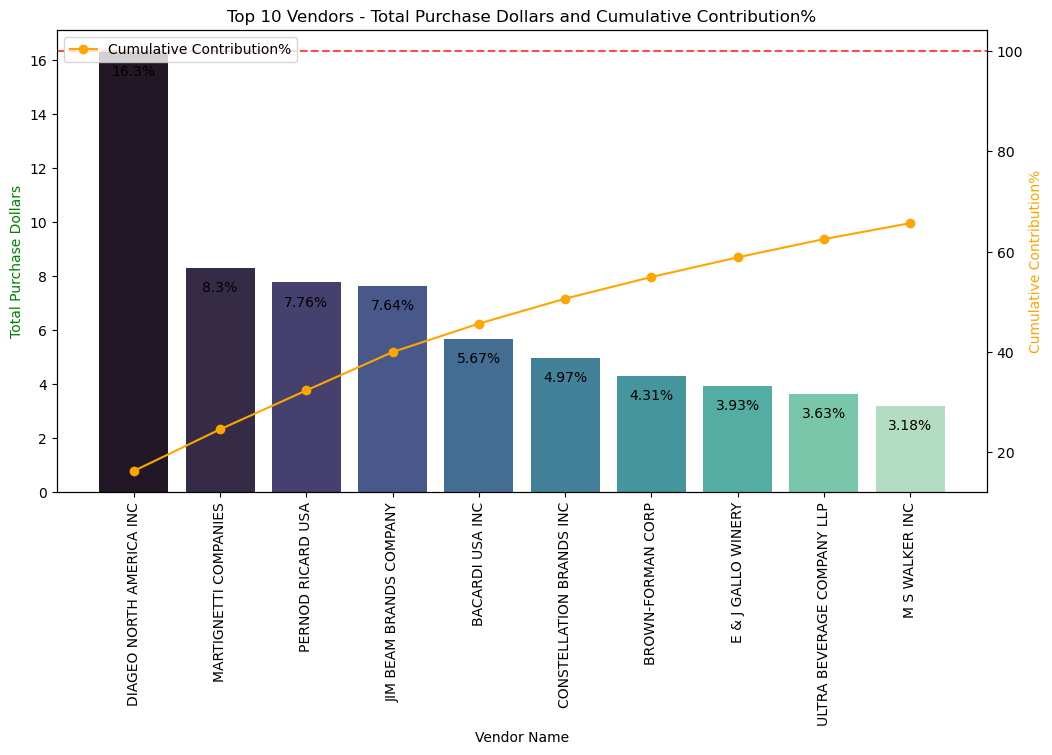

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'],palette="mako", ax=ax1)


for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value-1, str(value)+'%', ha='center', va='bottom', fontsize=10)


ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['CumulativeContribution%'], color='orange', marker='o', label='Cumulative Contribution%')    


ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Total Purchase Dollars', color='Green')
ax2.set_ylabel('Cumulative Contribution%', color='orange')
ax1.set_xlabel('Vendor Name')
ax1.set_title('Top 10 Vendors - Total Purchase Dollars and Cumulative Contribution%')


ax2.axhline(y=100, color='red', linestyle='--', alpha=0.7)
ax2.legend(loc='upper left')

plt.show()

How much of total procurement is dependent on the top vendors

In [28]:
print(f"Total purchase contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(), 2)}%")

Total purchase contribution of top 10 vendors is 65.69%


Does purchasing in the bulk reduce the unit price and what is the optimal purchase volume of cost saving?

In [29]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [30]:
df['OrderSize']= pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['small','medium','large'])

In [31]:
df.groupby('OrderSize')['UnitPurchasePrice'].mean()

OrderSize
small     39.068186
medium    15.486414
large     10.777625
Name: UnitPurchasePrice, dtype: float64

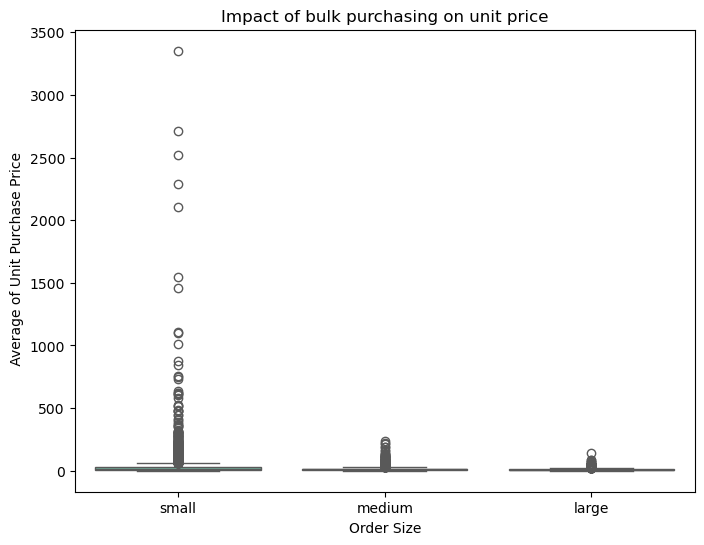

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='OrderSize', y='UnitPurchasePrice', data=df, palette='Set2')
plt.title('Impact of bulk purchasing on unit price')
plt.xlabel('Order Size')
plt.ylabel(' Average of Unit Purchase Price')
plt.show()

So from here we come to know the large order size reduces the average unit purchase price. It is beneficial for the vendor to order products in the bulk size but for it proper management of bulk shippment storage has to be done. So focus has to be given by doing so and how they can help the small vendors from doing it.

Which vendors have low inventory turnover, indicating excess stock and slow moving products?

In [65]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)
df[df['StockTurnover']<1].groupby('Description')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
Description,
Mas Belles Eaux Les Cot Roug,0.428571
Viberti Chard,0.472222
Velvet Crush Cab Svgn,0.500000
Ca'Momi Chard Napa Vly,0.513354
Beringer Cab Svgn Pvt RSV Np,0.528205
Jewell Towne Cab Svgn NH,0.567568
Line 39 Merlot,0.567568
BV Coastal Estate Red,0.569444
Nicolas Potel Pnt Nr Bourgog,0.582857


How much capital inverntory is remained as unsold per vendor and which one is contribute the most?

In [34]:
df['UnsoldInventoryvalue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']

print("UnsoldInventoryvalue:", format_dollars(df["UnsoldInventoryvalue"].sum()))

UnsoldInventoryvalue: 2.71M


In [35]:
Unsold_Inventory_per_vendor=df.groupby('VendorName')['UnsoldInventoryvalue'].sum().sort_values(ascending=False).head(10)
Unsold_Inventory_per_vendor.apply(lambda x: format_dollars(x)).sort_values(ascending=False).reset_index()

,VendorName,UnsoldInventoryvalue
0,DIAGEO NORTH AMERICA INC,722.21K
1,JIM BEAM BRANDS COMPANY,554.67K
2,PERNOD RICARD USA,470.63K
3,WILLIAM GRANT & SONS INC,401.96K
4,E & J GALLO WINERY,228.28K
5,SAZERAC CO INC,198.44K
6,BROWN-FORMAN CORP,177.73K
7,CONSTELLATION BRANDS INC,133.62K
8,MOET HENNESSY USA INC,126.48K
9,REMY COINTREAU USA INC,118.60K


What is the 95% confidence intervals for profit margins of top performing and low performing vendors?

In [36]:
low_sales_threshold=df['TotalSalesDollars'].quantile(0.25)
high_sales_threshold=df['TotalSalesDollars'].quantile(0.75)

In [37]:
top_vendors=df[df['TotalSalesDollars']>=high_sales_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_sales_threshold]['ProfitMargin'].dropna()

In [38]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [39]:
def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    margin_of_error = sem * stats.t.ppf((1 + confidence) / 2., len(data)-1)
    return mean, mean - margin_of_error, mean + margin_of_error

Top Vendors Profit Margin: Mean=31.18%, CI=(30.74%, 31.61%)
Low Vendors Profit Margin: Mean=41.57%, CI=(40.50%, 42.64%)


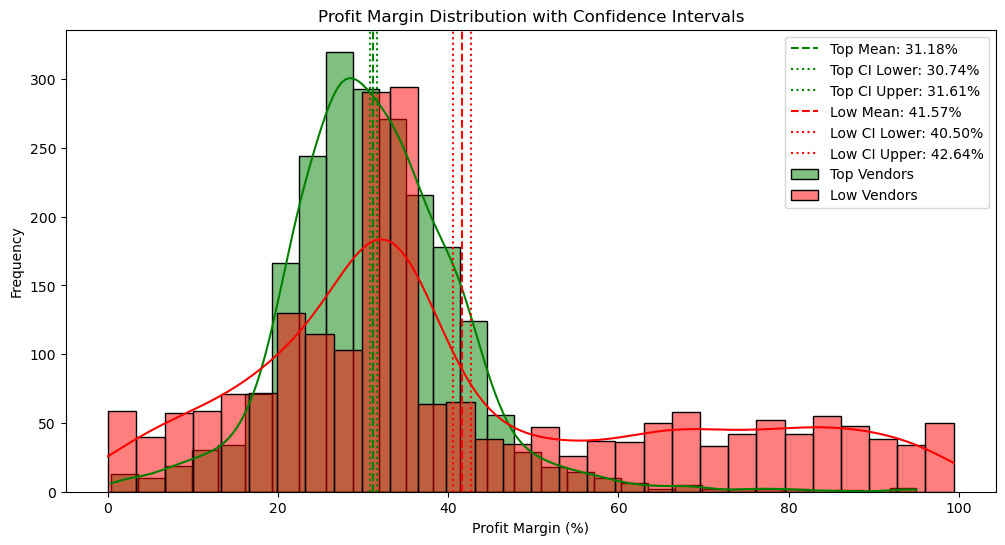

In [40]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)
print(f"Top Vendors Profit Margin: Mean={top_mean:.2f}%, CI=({top_lower:.2f}%, {top_upper:.2f}%)")
print(f"Low Vendors Profit Margin: Mean={low_mean:.2f}%, CI=({low_lower:.2f}%, {low_upper:.2f}%)")

plt.figure(figsize=(12, 6))

#Top vendor list
sns.histplot(top_vendors, kde=True, color='green', label='Top Vendors', bins=30)
plt.axvline(top_mean, color='green', linestyle='--', label=f'Top Mean: {top_mean:.2f}%')
plt.axvline(top_lower, color='green', linestyle=':', label=f'Top CI Lower: {top_lower:.2f}%')
plt.axvline(top_upper, color='green', linestyle=':', label=f'Top CI Upper: {top_upper:.2f}%')

#Low vendor list
sns.histplot(low_vendors, kde=True, color='red', label='Low Vendors', bins=30)
plt.axvline(low_mean, color='red', linestyle='--', label=f'Low Mean: {low_mean:.2f}%')
plt.axvline(low_lower, color='red', linestyle=':', label=f'Low CI Lower: {low_lower:.2f}%')
plt.axvline(low_upper, color='red', linestyle=':', label=f'Low CI Upper: {low_upper:.2f}%')

#Final list
plt.title('Profit Margin Distribution with Confidence Intervals')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Frequency')
plt.legend()
plt.show()









The confidence interval for low performing vendors(40.50%, 42.64%) is significantly higher than that of top performing vendors(30.74%,31.61%). 
This suggests that the vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

For high performing vendors: If they aim to improve profitability , they could explore selective price adjustments,cost optimazation and bundling strategies.

For low performing vendors: Despite higher profit margin their low sales volume might indicate a need for better marketing,competative pricing or improved distribution strategies.




Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:
Ho (Null Hypothesis):There is no significant difference in the mean profit margins of top performing and low performing vendors
H1 (Alternative Hypothesis):The mean profit margins of top-performing and low -performing vendors

In [41]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject null hypothesis: Significant difference in profit margins between top and low sales vendors.")
else:
    print("Fail to reject null hypothesis: No significant difference in profit margins between top and low sales vendors.")
    

T-statistic: -17.67, P-value: 0.0000
Reject null hypothesis: Significant difference in profit margins between top and low sales vendors.
